<a href="https://colab.research.google.com/github/David-gutierrez-rodriguez/PG/blob/main/PG_Polinomios.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
pip install deap

Note: you may need to restart the kernel to use updated packages.


In [6]:
import operator
import math
import random
import sympy
import re
import csv
import os
import functools

import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
import pandas as pd

from IPython.display import display, Math
from deap import algorithms, base, creator, tools, gp

In [65]:
class txtParser:
    def __init__(self, txt):
        #Constructor
        self.x = []
        self.y = []
        self.e = []
        self.populateList(txt)

    def populateList(self, file):
        with open(file) as fp:
            cnt = 0
            for line in fp:
                if(cnt < 2):
                    cnt += 1
                    continue
                line = line.split()
                self.x.append(float(line[0]))
                self.y.append(float(line[1]))
                if len(line) == 3:
                   self.e.append(float(line[2]))
        return

class csvParser:
    def __init__(self, csv_file):
        #Constructor
        self.mjd = []
        self.x = []
        self.y = []
        self.e = []
        self.populateList(csv_file)

    def populateList(self, file):
        with open(file, 'r') as fp:
            reader = csv.reader(fp)
            header = next(reader) # Read header row

            # Find column indices
            try:
                mjd_idx = header.index('mjd')
                x_idx = header.index('x')
                y_idx = header.index('y')
            except ValueError as e:
                print(f"Error: Required column not found in CSV header: {e}")
                return

            for row in reader:
                try:
                    self.mjd.append(float(row[mjd_idx]))
                    self.x.append(float(row[x_idx]))
                    self.y.append(float(row[y_idx]))
                except (ValueError, IndexError) as e:
                    print(f"Skipping row due to data conversion or index error: {row} - {e}")
                    continue

def protectedDiv(left, right):
    try:
        return left / right
    except ZeroDivisionError:
        return 1e6
    except Exception:
        return 1e9


def protectedLog(argument):
    try:
        arg = float(argument)
        if arg <= 0:
            return 1e6
        return math.log(arg)
    except Exception:
        return 1e9
     
def protectedSqrt(x):
    try:
        if x < 0:
            return math.sqrt(0)
        return math.sqrt(x)
    except Exception:
        return 1e6

def protectedExpNeg(x):
    try:
        if x > 50: return math.exp(-50)
        if x < -50: return math.exp(50)
        return math.exp(-x)
    except:
        return 1e6

def protectedExpNeg2(x):
    try:
        if x**2 > 50: return math.exp(-50)
        return math.exp(-x**2)
    except:
        return 1e6

def to_latex(expr):
    try:
        # Si expr es una tupla, toma el primer elemento
        if isinstance(expr, tuple):
            expr = expr[0]

        # Si expr es numérico, conviértelo directamente
        if isinstance(expr, (int, float)):
            return str(expr)

        # Intentamos convertir con sympy

        x = sympy.symbols("x")
        safe_env = {
          "add": lambda a, b: a + b,
          "mul": lambda a, b: a*b,
          "sub": lambda a, b: a - b,
          "protectedDiv": lambda a, b: a/b,
          "protectedLog": lambda a: sympy.log(a),
          "protectedExp": lambda a: sympy.exp(a),
          "sin": lambda a: sympy.sin(a),
          "cos": lambda a: sympy.cos(a),
          'x': x,
          "protectedSqrt": lambda a: sympy.sqrt(a),
          "protectedExpNeg": lambda a: sympy.exp(-a),
          "protectedExpNeg2": lambda a: sympy.exp(-a**2) 
        }
        sym_expr = eval(expr, {"_builtins_": None}, safe_env)
        latex_str = sympy.latex(sym_expr)
        return f"$f(x) = {latex_str}$"
    except Exception:
        # Si algo falla (por ejemplo, expresión inválida), lo devolvemos como string normal
        return str(expr)



def symbolicRegression(individual, toolbox, x_value, y_value, error, asymptote_check, include_error):
  func = toolbox.compile(expr=individual)
  if asymptote_check:
    min_x, max_x, min_y, max_y = min(x_value), max(x_value), min(y_value), max(y_value)
    test_points = np.linspace(min_x, max_x, 1000)

    try:
      evaluated_values = [func(x) for x in test_points]

      if any(math.isinf(y) or math.isnan(y) or y > max_y or y < min_y for y in evaluated_values):
        return (1e9,)

    except (ValueError, OverflowError, ZeroDivisionError):
      return (1e9,)

    if include_error:
      sqerrors = (((func(i) - j)/k)**2 for i, j, k in zip(x_value, y_value, error))
    else:
      sqerrors = ((func(i) - j)**2 for i, j in zip(x_value, y_value))
  else:
    if include_error:
      sqerrors = (((func(i) - j)/k)**2 for i, j, k in zip(x_value, y_value, error))
    else:
      sqerrors = ((func(i) - j)**2 for i, j in zip(x_value, y_value))
  return math.fsum(sqerrors),

In [66]:
# CAMBIÉ ESTA ----------------------------------------------------- BLOC DE NOTAS

def best_polynomial_general(data_file, max_gen=1000, max_tree_level=3,
                            asymptote_check=False, include_error=False):
    # Detectar tipo de archivo
    ext = os.path.splitext(data_file)[1].lower()
    
    if ext == ".txt":
        data = txtParser(data_file)
    elif ext == ".csv":
        data = csvParser(data_file)
        # csvParser espera columna 'mjd'
        # si no existe, usamos 'x'
        if not hasattr(data, 'mjd') or len(data.mjd) == 0:
            data.mjd = data.x
    else:
        raise ValueError("Formato de archivo no soportado. Solo .txt o .csv")

    # Normalizar nombres de columnas
    # La función GP siempre espera data.x y data.y
    if hasattr(data, 'mjd') and len(data.mjd) > 0:
        data.x = data.mjd
    if hasattr(data, 'y') and len(data.y) > 0:
        data.y = data.y
    else:
        # Si no hay columna 'y', la usamos como identidad de x
        data.y = data.x

    # -------------------------------
    # Crear set de primitivas
    # -------------------------------
    pset = gp.PrimitiveSet("main", 1)
    pset.addPrimitive(operator.add, 2)
    pset.addPrimitive(operator.sub, 2)
    pset.addPrimitive(operator.mul, 2)
    pset.addPrimitive(protectedDiv, 2)
    pset.addPrimitive(math.sin, 1)
    pset.addPrimitive(math.cos, 1)
    pset.addPrimitive(protectedSqrt, 1)
    pset.addPrimitive(protectedExp, 1)
    pset.addPrimitive(protectedExpNeg, 1)
    pset.addPrimitive(protectedExpNeg2, 1)
    # Ephemeral constant sin warning
    pset.addEphemeralConstant("rand", functools.partial(random.randint, -100, 100))
    pset.renameArguments(ARG0='x')

    # -------------------------------
    # Crear individuos y fitness
    # -------------------------------
    if not hasattr(creator, "FitnessMin"):
        creator.create("FitnessMin", base.Fitness, weights=(-10.0,))
    if not hasattr(creator, "Individual"):
        creator.create("Individual", gp.PrimitiveTree, fitness=creator.FitnessMin)

    toolbox = base.Toolbox()
    toolbox.register("expr", gp.genHalfAndHalf, pset=pset, min_=1, max_=3)
    toolbox.register("individual", tools.initIterate, creator.Individual, toolbox.expr)
    toolbox.register("population", tools.initRepeat, list, toolbox.individual)
    toolbox.register("compile", gp.compile, pset=pset)
    toolbox.register("evaluate", symbolicRegression, toolbox=toolbox,
                     x_value=data.x, y_value=data.y, error=getattr(data,'e',[]),
                     asymptote_check=asymptote_check, include_error=include_error)
    toolbox.register("select", tools.selTournament, tournsize=3)
    toolbox.register("mate", gp.cxOnePoint)
    toolbox.register("expr_mut", gp.genFull, min_=0, max_=2)
    toolbox.register("mutate", gp.mutUniform, expr=toolbox.expr_mut, pset=pset)
    toolbox.decorate("mate", gp.staticLimit(key=operator.attrgetter("height"), max_value=max_tree_level))
    toolbox.decorate("mutate", gp.staticLimit(key=operator.attrgetter("height"), max_value=max_tree_level))

    # -------------------------------
    # Ejecutar GP
    # -------------------------------
    random.seed(2)
    population = toolbox.population(n=300)
    halloffame = tools.HallOfFame(1)
    stats_fit = tools.Statistics(lambda ind: ind.fitness.values)
    stats_size = tools.Statistics(len)
    mstats = tools.MultiStatistics(fitness=stats_fit, size=stats_size)
    mstats.register("avg", np.mean)
    mstats.register("std", np.std)
    mstats.register("min", np.min)
    mstats.register("max", np.max)

    pop, log = algorithms.eaSimple(population, toolbox, 0.5, 0.1, max_gen,
                                   stats=mstats, halloffame=halloffame, verbose=True)

    best = halloffame.items[0]
    print("\n-- Best Individual =", best)
    print("-- length={}, height={}".format(len(best), best.height))
    print("-- Best Fitness =", best.fitness.values[0])

    # -------------------------------
    # Graficar árbol
    # -------------------------------
    nodes, edges, labels = gp.graph(best)
    g = nx.Graph()
    g.add_nodes_from(nodes)
    g.add_edges_from(edges)
    pos = nx.spring_layout(g)
    nx.draw_networkx_nodes(g, pos, node_color='green')
    nx.draw_networkx_nodes(g, pos, nodelist=[0], node_color='red', node_size=400)
    nx.draw_networkx_edges(g, pos)
    nx.draw_networkx_labels(g, pos, labels=labels, font_size=8)
    plt.show()

    # -------------------------------
    # Graficar regresión
    # -------------------------------
    func = toolbox.compile(expr=best)
    x_vals = np.linspace(min(data.x), max(data.x), 1000)
    y_vals = [func(i) for i in x_vals]
    plt.plot(x_vals, y_vals, label="symbolic regression")
    plt.scatter(data.x, data.y, color="red", label="data")
    plt.ylim(min(data.y), max(data.y))
    plt.grid(True)
    plt.legend(loc="best")
    plt.show()

    # Mostrar expresión en LaTeX
    display(Math(to_latex(str(best))))

In [67]:
def best_polynomial_general2(data_file, max_gen=1000, max_tree_level=3,
                            asymptote_check=False, include_error=False):
    
    # 1 Detectar tipo de archivo
    ext = os.path.splitext(data_file)[1].lower()
    
    if ext == ".txt":
        df = pd.read_csv(data_file, sep=r'\s+', skiprows=2, header=None)
        df.columns = ['x', 'y'] if df.shape[1]==2 else ['x', 'y', 'e']
    elif ext == ".csv":
        df = pd.read_csv(data_file)
    else:
        raise ValueError("Formato no soportado. Solo .txt o .csv")
    
    # 2 Detectar columnas X y Y automáticamente
    # Tomamos la primera columna numérica como X y la siguiente como Y
    numeric_cols = df.select_dtypes(include=np.number).columns.tolist()
    if len(numeric_cols) < 2:
        raise ValueError("No se encontraron suficientes columnas numéricas para X e Y")
    
    x_col, y_col = numeric_cols[0], numeric_cols[1]
    df_x = df[x_col].tolist()
    df_y = df[y_col].tolist()
    
    # Columna de error opcional
    if include_error and df.shape[1] >= 3:
        error_col = numeric_cols[2] if len(numeric_cols) >= 3 else None
        df_e = df[error_col].tolist() if error_col else []
    else:
        df_e = []
    
    # 3 Configurar GP
    pset = gp.PrimitiveSet("main", 1)
    pset.addPrimitive(operator.add, 2)
    pset.addPrimitive(operator.sub, 2)
    pset.addPrimitive(operator.mul, 2)
    pset.addPrimitive(protectedDiv, 2)
    pset.addPrimitive(math.sin, 1)
    pset.addPrimitive(math.cos, 1)
    pset.addPrimitive(protectedSqrt, 1)
    pset.addPrimitive(protectedExp, 1)
    pset.addPrimitive(protectedExpNeg, 1)
    pset.addPrimitive(protectedExpNeg2, 1)
    pset.addEphemeralConstant("rand", functools.partial(random.randint, -100, 100))
    pset.renameArguments(ARG0='x')
    
    # 4 Crear individuos y fitness
    if not hasattr(creator, "FitnessMin"):
        creator.create("FitnessMin", base.Fitness, weights=(-10.0,))
    if not hasattr(creator, "Individual"):
        creator.create("Individual", gp.PrimitiveTree, fitness=creator.FitnessMin)
    
    toolbox = base.Toolbox()
    toolbox.register("expr", gp.genHalfAndHalf, pset=pset, min_=1, max_=3)
    toolbox.register("individual", tools.initIterate, creator.Individual, toolbox.expr)
    toolbox.register("population", tools.initRepeat, list, toolbox.individual)
    toolbox.register("compile", gp.compile, pset=pset)
    toolbox.register("evaluate", symbolicRegression,
                     toolbox=toolbox, x_value=df_x, y_value=df_y, error=df_e,
                     asymptote_check=asymptote_check, include_error=include_error)
    toolbox.register("select", tools.selTournament, tournsize=3)
    toolbox.register("mate", gp.cxOnePoint)
    toolbox.register("expr_mut", gp.genFull, min_=0, max_=2)
    toolbox.register("mutate", gp.mutUniform, expr=toolbox.expr_mut, pset=pset)
    toolbox.decorate("mate", gp.staticLimit(key=operator.attrgetter("height"), max_value=max_tree_level))
    toolbox.decorate("mutate", gp.staticLimit(key=operator.attrgetter("height"), max_value=max_tree_level))
    
    # 5 Ejecutar GP
    random.seed(2)
    population = toolbox.population(n=300)
    halloffame = tools.HallOfFame(1)
    stats_fit = tools.Statistics(lambda ind: ind.fitness.values)
    stats_size = tools.Statistics(len)
    mstats = tools.MultiStatistics(fitness=stats_fit, size=stats_size)
    mstats.register("avg", np.mean)
    mstats.register("std", np.std)
    mstats.register("min", np.min)
    mstats.register("max", np.max)
    
    pop, log = algorithms.eaSimple(population, toolbox, 0.5, 0.1, max_gen,
                                   stats=mstats, halloffame=halloffame, verbose=True)
    
    best = halloffame.items[0]
    print("\n-- Best Individual =", best)
    print("-- length={}, height={}".format(len(best), best.height))
    print("-- Best Fitness =", best.fitness.values[0])
    
    # 6 Graficar árbol
    nodes, edges, labels = gp.graph(best)
    g = nx.Graph()
    g.add_nodes_from(nodes)
    g.add_edges_from(edges)
    pos = nx.spring_layout(g)
    nx.draw_networkx_nodes(g, pos, node_color='green')
    nx.draw_networkx_nodes(g, pos, nodelist=[0], node_color='red', node_size=400)
    nx.draw_networkx_edges(g, pos)
    nx.draw_networkx_labels(g, pos, labels=labels, font_size=8)
    plt.show()
    
    # 7 Graficar regresión
    func = toolbox.compile(expr=best)
    x_vals = np.linspace(min(df_x), max(df_x), 1000)
    y_vals = [func(i) for i in x_vals]
    plt.plot(x_vals, y_vals, label="symbolic regression")
    plt.scatter(df_x, df_y, color="red", label="data")
    plt.ylim(min(df_y), max(df_y))
    plt.grid(True)
    plt.legend(loc="best")
    plt.show()
    
    # 8️ Mostrar expresión en LaTeX
    display(Math(to_latex(str(best))))

   	      	                              fitness                              	                      size                     
   	      	-------------------------------------------------------------------	-----------------------------------------------
gen	nevals	avg        	gen	max        	min   	nevals	std        	avg 	gen	max	min	nevals	std    
0  	300   	1.52505e+47	0  	4.57128e+49	159.64	300   	2.63482e+48	4.56	0  	12 	2  	300   	2.56899
1  	180   	4.8698e+43 	1  	1.16525e+46	106.155	180   	6.74477e+44	4.57333	1  	12 	1  	180   	2.38704
2  	194   	4.83862e+42	2  	4.83861e+44	100.25 	194   	4.81436e+43	5.00667	2  	17 	1  	194   	2.71783
3  	173   	3.76337e+42	3  	4.83861e+44	69.9355	173   	4.04148e+43	5.27333	3  	14 	1  	173   	2.87378
4  	147   	3.22574e+42	4  	4.83861e+44	69.9355	147   	3.93752e+43	5.58   	4  	17 	1  	147   	3.13958
5  	170   	1.6129e+42 	5  	4.83861e+44	47.5112	170   	2.78891e+43	6.14333	5  	15 	1  	170   	3.37976
6  	164   	3.76336e+42	6  	4.83861e+44	65.5121	

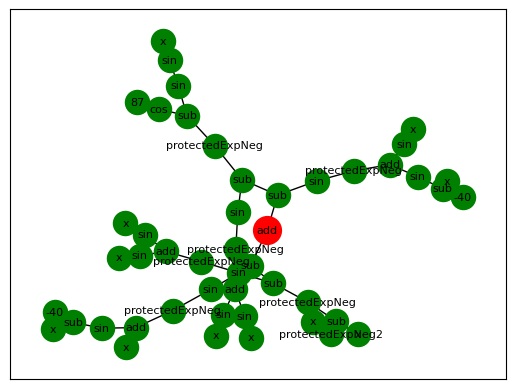

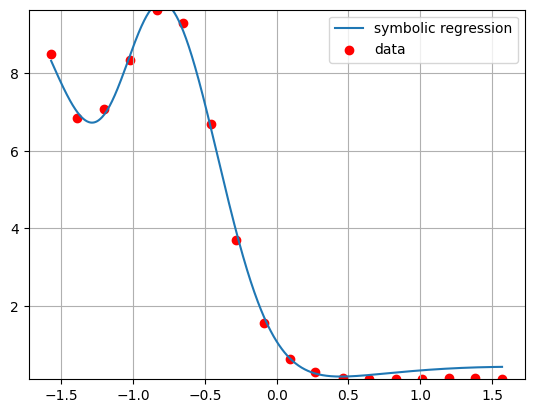

<IPython.core.display.Math object>

In [73]:
best_polynomial_general2(data_file= "ejemplo23AGP.txt", max_gen=1000, max_tree_level=7,
                            asymptote_check=False, include_error=False)

   	      	                  fitness                  	                      size                     
   	      	-------------------------------------------	-----------------------------------------------
gen	nevals	avg	gen	max	min	nevals	std	avg 	gen	max	min	nevals	std    
0  	300   	0  	0  	0  	0  	300   	0  	4.56	0  	12 	2  	300   	2.56899
1  	177   	0  	1  	0  	0  	177   	0  	4.44	1  	13 	1  	177   	2.48322
2  	186   	0  	2  	0  	0  	186   	0  	4.39	2  	14 	1  	186   	2.43678
3  	168   	0  	3  	0  	0  	168   	0  	4.39333	3  	13 	1  	168   	2.40665
4  	157   	0  	4  	0  	0  	157   	0  	4.37333	4  	13 	1  	157   	2.44553
5  	179   	0  	5  	0  	0  	179   	0  	4.11667	5  	15 	1  	179   	2.24122
6  	166   	0  	6  	0  	0  	166   	0  	4.27667	6  	15 	1  	166   	2.40834
7  	164   	0  	7  	0  	0  	164   	0  	4.36667	7  	17 	1  	164   	2.56363
8  	167   	0  	8  	0  	0  	167   	0  	4.17333	8  	17 	1  	167   	2.44471
9  	159   	0  	9  	0  	0  	159   	0  	4.07667	9  	22 	1  	159   	2.67534
10 

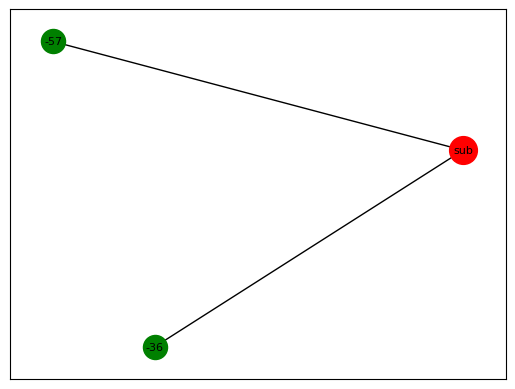

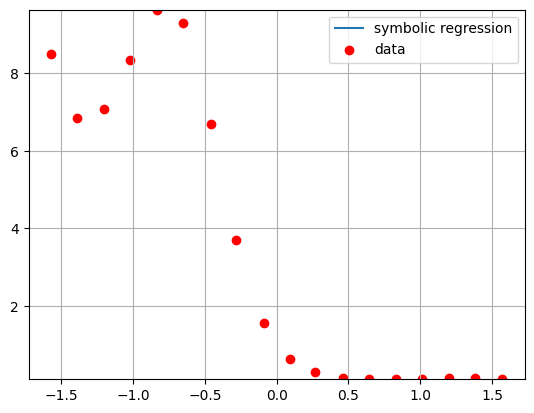

<IPython.core.display.Math object>

In [71]:
#best_polynomial_general(data_file = "regression.txt", max_gen = 1000, max_tree_level = 10, include_error=True)
best_polynomial_general2(data_file="ejemplo23AGP.txt",max_gen=1000,max_tree_level=10,include_error=True)

In [36]:
#ORIGINAL LA CAMBIE POR LA DE ARRIBA
#best_polynomial(data = "regression.txt", max_gen=1000, max_tree_level = 3, asymptote_check=False, include_error=False)

In [37]:
# IGUAL ES LA ORIGINAL, LA CAMBIÉ, VENIAN A PARES
#best_polynomial(data = "regression.txt", max_gen = 1000, max_tree_level = 10, include_error=True)